<a href="https://colab.research.google.com/github/2873991-Manthena/Dissertation/blob/main/DistillBERT_Preprocessed_Dataset_(MBTI1_%26_MBTI500)_3ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###############################################################
# PERSONALITY PREDICTION USING BERT
# Dataset:
#   1. MBTI1
#   2. MBTI500
#   
###############################################################

In [ ]:
###############################################################
# SECTION 1 - IMPORT LIBRARIES
###############################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch

In [ ]:
!pip uninstall -y torch torchvision torchaudio datasets transformers accelerate

Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
Found existing installation: torchvision 0.28.0
Uninstalling torchvision-0.28.0:
  Successfully uninstalled torchvision-0.28.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Found existing installation: datasets 5.0.0
Uninstalling datasets-5.0.0:
  Successfully uninstalled datasets-5.0.0
Found existing installation: transformers 5.14.1
Uninstalling transformers-5.14.1:
  Successfully uninstalled transformers-5.14.1
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0


In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets accelerate evaluate

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, which is not installed.
peft 0.19.1 requires accelerate>=0.21.0, which is not installed.
peft 0.19.1 requires transformers, which is not installed.


In [ ]:
###############################################################
# SECTION 2 - MOUNT GOOGLE DRIVE
###############################################################

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
###############################################################
# SECTION 3 - LOAD DATASET
###############################################################

PROJECT_PATH = "/content/drive/MyDrive/Dissertation/"
DATASET_PATH = PROJECT_PATH + "Datasets/"

df = pd.read_csv(DATASET_PATH + "mbti1_preprocessed.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8675, 2)


,type,clean_text
0,INFJ,intj moment sportscenter top ten play prank li...
1,ENTP,I find lack I post alarm sex boring position o...
2,INTP,good one course I say I know my blessing my cu...
3,INTJ,dear intp I enjoy our conversation day esoteri...
4,ENTJ,you fire another silly misconception approach ...


In [ ]:
###############################################################
# SECTION 4 - DATA PREPARATION
###############################################################

# Keep only required columns
df = df[["type", "clean_text"]]

# Remove missing values
df = df.dropna()

# Convert text to string
df["clean_text"] = df["clean_text"].astype(str)

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 8674 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   type        8674 non-null   object
 1   clean_text  8674 non-null   object
dtypes: object(2)
memory usage: 203.3+ KB
None
   type                                         clean_text
0  INFJ  intj moment sportscenter top ten play prank li...
1  ENTP  I find lack I post alarm sex boring position o...
2  INTP  good one course I say I know my blessing my cu...
3  INTJ  dear intp I enjoy our conversation day esoteri...
4  ENTJ  you fire another silly misconception approach ...


In [ ]:
###############################################################
# SECTION 5 - LABEL ENCODING
###############################################################

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["type"])

print("Number of Personality Types:", len(label_encoder.classes_))
print(label_encoder.classes_)

Number of Personality Types: 16
['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']


In [ ]:
###############################################################
# SECTION 6 - TRAIN TEST SPLIT
###############################################################

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training Samples:", len(train_df))
print("Testing Samples:", len(test_df))

Training Samples: 6939
Testing Samples: 1735


In [ ]:
###############################################################
# SECTION 7 - LOAD TOKENIZER
###############################################################

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully!")

Tokenizer Loaded Successfully!


In [ ]:
###############################################################
# SECTION 8 - CREATE HUGGING FACE DATASET
###############################################################

train_dataset = Dataset.from_pandas(
    train_df[["clean_text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["clean_text", "label"]],
    preserve_index=False
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['clean_text', 'label'],
    num_rows: 6939
})
Dataset({
    features: ['clean_text', 'label'],
    num_rows: 1735
})


In [ ]:
###############################################################
# SECTION 9 - TOKENIZATION
###############################################################

def tokenize(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/6939 [00:00<?, ? examples/s]

Map:   0%|          | 0/1735 [00:00<?, ? examples/s]

In [ ]:
###############################################################
# SECTION 10 - PREPARE DATASET
###############################################################

train_dataset = train_dataset.remove_columns(["clean_text"])
test_dataset = test_dataset.remove_columns(["clean_text"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print("Dataset Ready!")

Dataset Ready!


In [ ]:
###############################################################
# SECTION 11 - LOAD DISTILBERT MODEL
###############################################################

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)

print("Model Loaded Successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded Successfully!


In [ ]:
###############################################################
# SECTION 12 - EVALUATION METRICS
###############################################################

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
###############################################################
# SECTION 13 - TRAINING ARGUMENTS
###############################################################

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=50,

    load_best_model_at_end=True,

    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
###############################################################
# SECTION 14 - TRAINER
###############################################################

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
###############################################################
# SECTION 15 - TRAIN MODEL
###############################################################

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.735990,1.587017,0.530259,0.479774,0.530259,0.492699
2,1.415799,1.477825,0.559078,0.559129,0.559078,0.549013
3,1.303617,1.448709,0.574063,0.570853,0.574063,0.567477


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1302, training_loss=1.6017208868457424, metrics={'train_runtime': 570.2108, 'train_samples_per_second': 36.508, 'train_steps_per_second': 2.283, 'total_flos': 1379131160813568.0, 'train_loss': 1.6017208868457424, 'epoch': 3.0})

In [ ]:
###############################################################
# SECTION 16 - FINAL EVALUATION
###############################################################

results = trainer.evaluate()

print("\n===== FINAL EVALUATION =====")

for key, value in results.items():
    print(f"{key}: {value}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.303617,1.448709,3,0.574063,0.570853,0.574063,0.567477



===== FINAL EVALUATION =====
eval_loss: 1.4487093687057495
eval_accuracy: 0.5740634005763688
eval_precision: 0.5708532436368347
eval_recall: 0.5740634005763688
eval_f1: 0.5674774345007704


In [ ]:
###############################################################
# SECTION 17 - PREDICTIONS
###############################################################

predictions = trainer.predict(test_dataset)

predicted_labels = predictions.predictions.argmax(axis=1)
true_labels = predictions.label_ids

print("Prediction Completed!")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Prediction Completed!


In [ ]:
###############################################################
# SECTION 18 - CLASSIFICATION REPORT
###############################################################

from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=label_encoder.classes_,
    digits=4
))

              precision    recall  f1-score   support

        ENFJ     0.5926    0.4211    0.4923        38
        ENFP     0.5952    0.5556    0.5747       135
        ENTJ     0.4444    0.3478    0.3902        46
        ENTP     0.5143    0.5255    0.5199       137
        ESFJ     0.0000    0.0000    0.0000         8
        ESFP     0.0000    0.0000    0.0000        10
        ESTJ     0.0000    0.0000    0.0000         8
        ESTP     0.7500    0.3333    0.4615        18
        INFJ     0.6617    0.5986    0.6286       294
        INFP     0.5962    0.6858    0.6379       366
        INTJ     0.5871    0.5413    0.5632       218
        INTP     0.5029    0.6628    0.5719       261
        ISFJ     0.5312    0.5152    0.5231        33
        ISFP     0.6486    0.4444    0.5275        54
        ISTJ     0.5517    0.3902    0.4571        41
        ISTP     0.5294    0.5294    0.5294        68

    accuracy                         0.5741      1735
   macro avg     0.4691   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


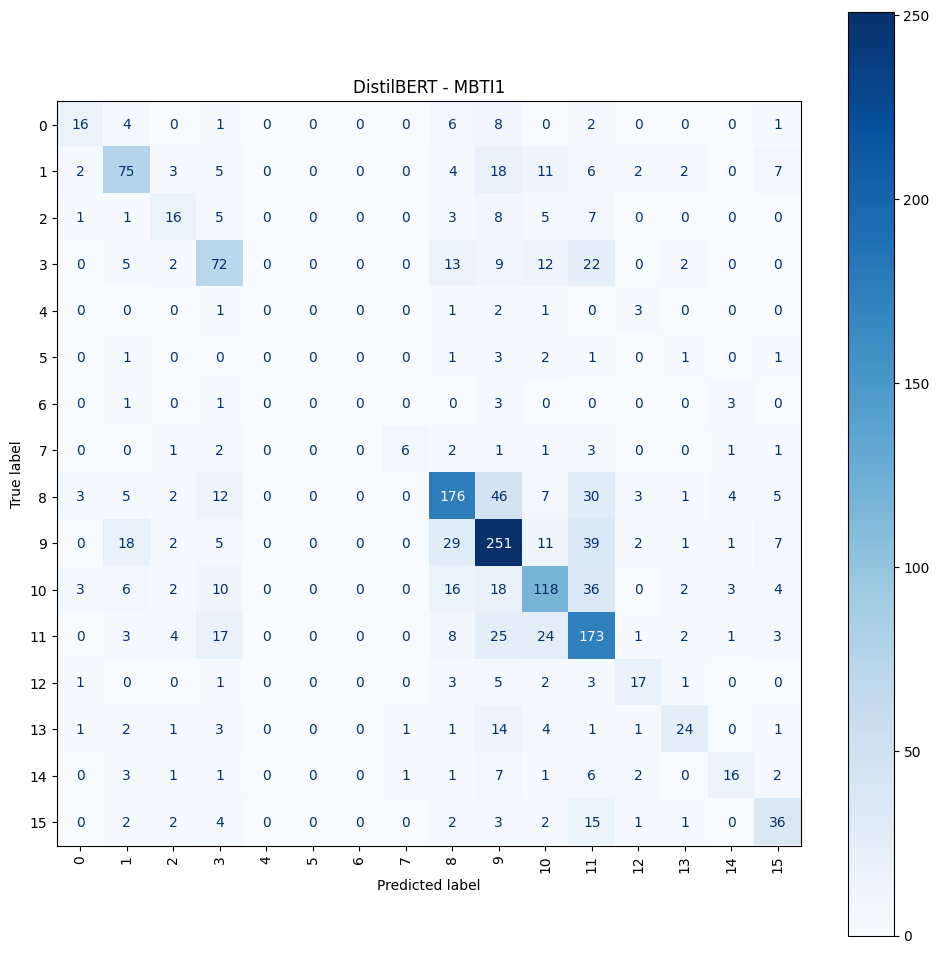

In [ ]:
###############################################################
# SECTION 19 - CONFUSION MATRIX
###############################################################

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,12))

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("DistilBERT - MBTI1")
plt.show()

In [ ]:
###############################################################
# SECTION 2 - LOAD MBTI500 DATASET
###############################################################

import pandas as pd

DATASET_PATH = "/content/drive/MyDrive/Dissertation/Datasets/"

df = pd.read_csv(DATASET_PATH + "mbti500_preprocessed.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (106067, 2)


,type,clean_text
0,INTJ,know intj tool use interaction people excuse a...
1,INTJ,rap music ehh opp yeah know valid well know fa...
2,INTJ,preferably p hd low except wew lad video p min...
3,INTJ,drink like wish could drink red wine give head...
4,INTJ,space program ah bad deal meing freelance max ...


In [ ]:
###############################################################
# SECTION 3 - DATA PREPARATION
###############################################################

df = df[["type", "clean_text"]]

df.dropna(inplace=True)

df["clean_text"] = df["clean_text"].astype(str)

print(df.head())

   type                                         clean_text
0  INTJ  know intj tool use interaction people excuse a...
1  INTJ  rap music ehh opp yeah know valid well know fa...
2  INTJ  preferably p hd low except wew lad video p min...
3  INTJ  drink like wish could drink red wine give head...
4  INTJ  space program ah bad deal meing freelance max ...


In [ ]:
###############################################################
# SECTION 4 - LABEL ENCODING
###############################################################

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["type"])

print(label_encoder.classes_)

['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']


In [ ]:
###############################################################
# SECTION 5 - TRAIN TEST SPLIT
###############################################################

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print(train_df.shape)
print(test_df.shape)

(84853, 3)
(21214, 3)


In [ ]:
###############################################################
# SECTION 6 - LOAD TOKENIZER
###############################################################

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
###############################################################
# SECTION 7 - CONVERT TO HUGGINGFACE DATASET
###############################################################

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["clean_text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["clean_text", "label"]],
    preserve_index=False
)

In [ ]:
###############################################################
# SECTION 8 - TOKENIZATION
###############################################################

def tokenize(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/84853 [00:00<?, ? examples/s]

Map:   0%|          | 0/21214 [00:00<?, ? examples/s]

In [ ]:
###############################################################
# SECTION 9 - FORMAT DATASET
###############################################################

train_dataset = train_dataset.remove_columns(["clean_text"])
test_dataset = test_dataset.remove_columns(["clean_text"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [ ]:
###############################################################
# SECTION 10 - LOAD DISTILBERT
###############################################################

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
###############################################################
# SECTION 11 - METRICS
###############################################################

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
###############################################################
# SECTION 12 - TRAINING ARGUMENTS
###############################################################

from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    report_to="none"
)

In [ ]:
###############################################################
# SECTION 13 - TRAINER
###############################################################

from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
###############################################################
# SECTION 14 - TRAIN MODEL
###############################################################

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.067702,1.057579,0.660272,0.675763,0.660272,0.661631
2,0.918862,0.945787,0.699868,0.701625,0.699868,0.697667
3,0.740007,0.949333,0.701424,0.702248,0.701424,0.700256


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=15912, training_loss=0.9634434018919011, metrics={'train_runtime': 6415.968, 'train_samples_per_second': 39.676, 'train_steps_per_second': 2.48, 'total_flos': 1.6864593801486336e+16, 'train_loss': 0.9634434018919011, 'epoch': 3.0})

In [ ]:
###############################################################
# SECTION 15 - FINAL EVALUATION
###############################################################

results = trainer.evaluate()

print("\n===== FINAL EVALUATION =====")

for key, value in results.items():
    print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.740007,0.945787,3,0.699868,0.701625,0.699868,0.697667



===== FINAL EVALUATION =====
eval_loss: 0.9457866549491882
eval_accuracy: 0.6998680116903931
eval_precision: 0.7016245454530782
eval_recall: 0.6998680116903931
eval_f1: 0.6976671028370092


In [ ]:
###############################################################
# SECTION 16 - PREDICTIONS
###############################################################

predictions = trainer.predict(test_dataset)

predicted_labels = predictions.predictions.argmax(axis=1)

true_labels = predictions.label_ids

print("Prediction Completed!")

Prediction Completed!


In [ ]:
###############################################################
# SECTION 17 - CLASSIFICATION REPORT
###############################################################

from sklearn.metrics import classification_report

print(classification_report(

    true_labels,

    predicted_labels,

    target_names=label_encoder.classes_,

    digits=4
))

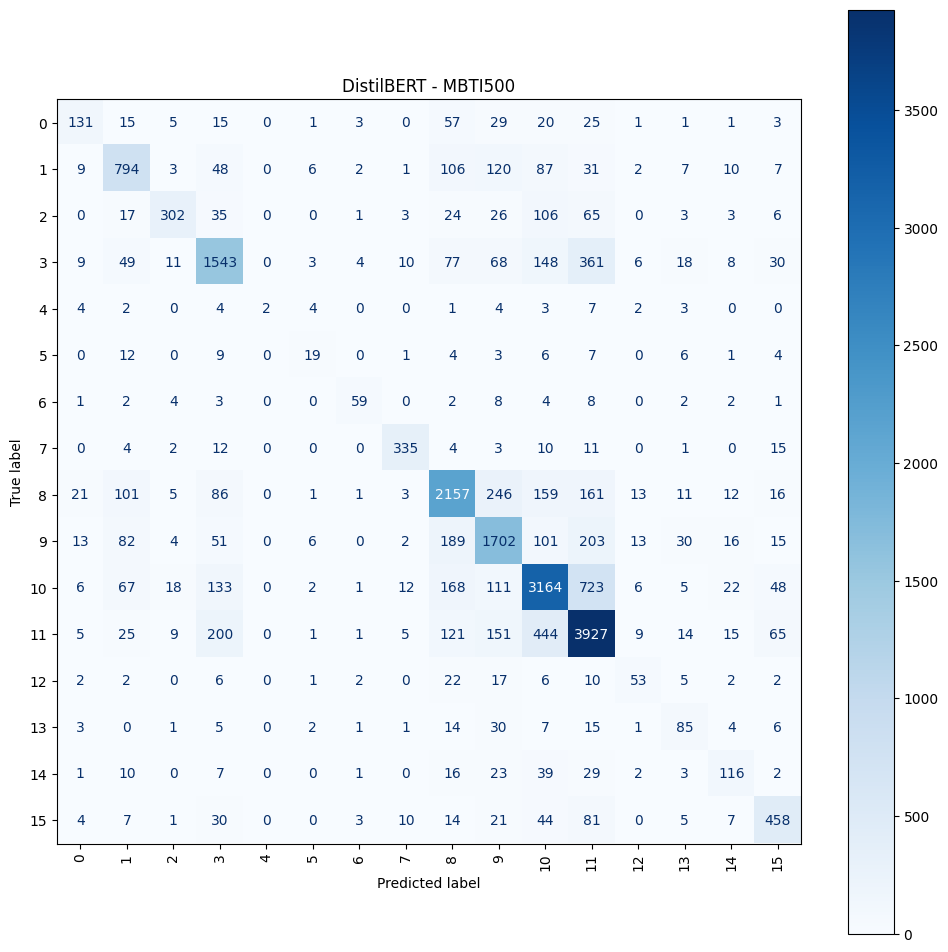

In [ ]:
###############################################################
# SECTION 18 - CONFUSION MATRIX
###############################################################

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12,12))

ConfusionMatrixDisplay.from_predictions(

    true_labels,

    predicted_labels,

    xticks_rotation=90,

    cmap="Blues",

    ax=ax
)

plt.title("DistilBERT - MBTI500")

plt.show()

In [ ]:
###############################################################
# SECTION 19 - SAVE RESULTS
###############################################################

results_df = pd.DataFrame({

    "Model": ["DistilBERT"],

    "Dataset": ["MBTI500"],

    "Accuracy": [results["eval_accuracy"]],

    "Precision": [results["eval_precision"]],

    "Recall": [results["eval_recall"]],

    "F1 Score": [results["eval_f1"]]

})

results_df.to_csv(
    DATASET_PATH + "DistilBERT_MBTI500_Results.csv",
    index=False
)

print(results_df)
print("\nResults saved successfully!")